In [2]:
# GOAL :: find optimal L2 weight 

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
import statsmodels.formula.api as smf
import statsmodels.api as sm
from BIGFAM import obj2, tools, frreg
import importlib

In [2]:
source = "UKB" # UKB, GS

# Step 1. Load data

## Step 1.1 FR-reg

In [3]:
frreg_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{source}/frreg/REL"
pheno_fns = os.listdir(frreg_path)
len(pheno_fns)

106

## Step 1.2 GCTA results

In [4]:
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM/data/gcta/X.all.gcta",
    sep='\t'
)

In [5]:
df_gc = (df_gcta[df_gcta["sex"] == "all"]
         .reset_index(drop=True))
        #  .drop(columns=["sex", "n_meta", "se_X_GCTA"]))

In [6]:
df_gc["lower_GCTA"] = df_gc["X_GCTA"] - 1.96 * df_gc["se_X_GCTA"]
df_gc["upper_GCTA"] = df_gc["X_GCTA"] + 1.96 * df_gc["se_X_GCTA"]
df_gc = df_gc.drop(columns=["sex", "n_meta", "se_X_GCTA"])
df_gc

,pheno,X_GCTA,lower_GCTA,upper_GCTA
0,Nucleated_red_blood_cell_percentage,0.002071,-0.000066,0.004208
1,"Hair_colour__natural,_before_greying_",0.004818,0.002681,0.006954
2,Urate,0.003119,0.000943,0.005295
3,Standing_height,0.020603,0.017991,0.023214
4,IGF-1,0.007575,0.005215,0.009935
...,...,...,...,...
125,Past_tobacco_smoking,0.003393,0.001164,0.005623
126,Arm_fat-free_mass__right_,0.008903,0.006595,0.011210
127,Forced_vital_capacity__FVC_,0.006721,0.004291,0.009151
128,Neuroticism_score,0.002500,-0.000026,0.005025


In [7]:
df_ta = pd.DataFrame(columns=["pheno", 
                              "Xmale_GCTA", "lowerXmale_GCTA", "upperXmale_GCTA",
                              "Xfemale_GCTA", "lowerXfemale_GCTA", "upperXfemale_GCTA",])
for p in df_gcta["pheno"].unique():
    tmp = df_gcta[df_gcta["pheno"] == p]
    if len(tmp) != 3:
        continue
    
    x_male, se_male = tmp.loc[tmp["sex"] == "male", ["X_GCTA", "se_X_GCTA"]].values[0]
    x_female, se_female = tmp.loc[tmp["sex"] == "female", ["X_GCTA", "se_X_GCTA"]].values[0]
    
    df_ta.loc[len(df_ta)] = [p, 
                             x_male, x_male - 1.96*se_male, x_male + 1.96*se_male, 
                             x_female, x_female - 1.96*se_female, x_female + 1.96*se_female, 
                             ]

In [8]:
df_ta

,pheno,Xmale_GCTA,lowerXmale_GCTA,upperXmale_GCTA,Xfemale_GCTA,lowerXfemale_GCTA,upperXfemale_GCTA
0,Nucleated_red_blood_cell_percentage,0.004651,-0.000055,0.009356,0.004284,0.000373,0.008195
1,"Hair_colour__natural,_before_greying_",0.004158,-0.000178,0.008495,0.008090,0.004137,0.012042
2,Urate,0.006318,0.001669,0.010968,0.003556,-0.000296,0.007409
3,Standing_height,0.021796,0.016847,0.026745,0.015764,0.011634,0.019895
4,IGF-1,0.010657,0.005788,0.015527,0.004999,0.000991,0.009008
...,...,...,...,...,...,...,...
125,Past_tobacco_smoking,0.005832,0.001073,0.010591,0.004295,0.000165,0.008424
126,Arm_fat-free_mass__right_,0.014670,0.009790,0.019549,0.007924,0.003957,0.011891
127,Forced_vital_capacity__FVC_,0.015693,0.010408,0.020978,0.005404,0.001213,0.009596
128,Neuroticism_score,0.005406,-0.000110,0.010921,0.006252,0.001428,0.011077


# Step 2. estimate X

## Step 2.1. Fixed weight

In [176]:
df_bigfam = pd.DataFrame(
    columns=["pheno", "weight", "X_BIGFAM",]
)

for pheno_fn in tqdm(pheno_fns):
    pheno = pheno_fn.split(".")[0]
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    # regress out mean
    df_block = obj2._regressOutMean(df_frreg, bin=["DOR"])
    
    for alp in range(-3, 3):
        alpha = 2**alp
        result = obj2._optToFindX(df_block, alpha)
        df_bigfam.loc[len(df_bigfam)] = [pheno, alp, result.x[0]]

100%|██████████| 106/106 [00:05<00:00, 18.01it/s]


In [177]:
df_bigfam.groupby("weight").mean()

,X_BIGFAM
weight,
-3,0.017354
-2,0.015093
-1,0.011962
0,0.008455
1,0.005329
2,0.003064


In [178]:
df_mrg = pd.merge(df_bigfam, df_gc, on="pheno")

(-0.01, 0.1)

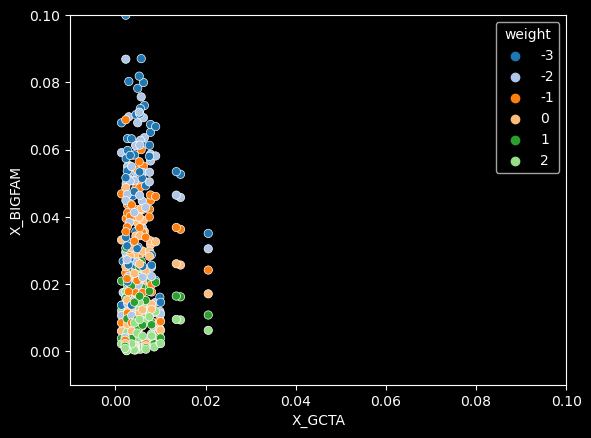

In [179]:
for_plot = df_mrg[(df_mrg["X_BIGFAM"] > 1e-6) & ((df_mrg["X_GCTA"] > 1e-6))]
sns.scatterplot(
    data=for_plot,
    x="X_GCTA",
    y="X_BIGFAM",
    hue="weight",
    palette="tab20")
plt.xlim([-0.01, 0.1])
plt.ylim([-0.01, 0.1])

### Step 2.1.1 plot correlation

In [180]:
df_corr = pd.DataFrame(columns=["weight", "type", "corr"])

for w in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == w]
    
    corr = tmp.corr().iloc[0, 1]
    corr_pos = (tmp[(tmp["X_BIGFAM"] > 1e-6) & (tmp["X_GCTA"] > 1e-6)]
                .corr()
                .iloc[0, 1])
    
    df_corr.loc[len(df_corr)] = [w, "all", corr]
    df_corr.loc[len(df_corr)] = [w, "pos", corr_pos]

<Axes: xlabel='weight', ylabel='corr'>

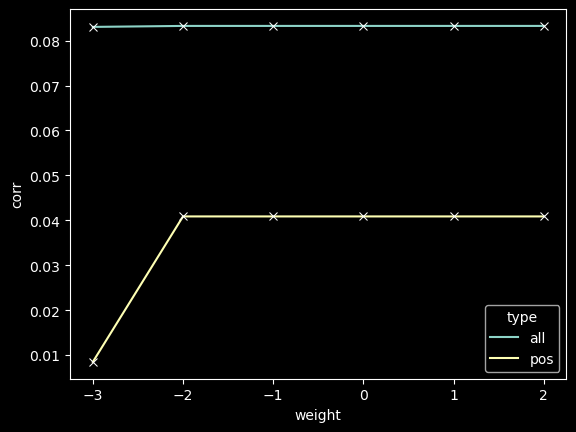

In [181]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="type",
    marker="x"
)

In [182]:
for_plot.groupby("weight").corr()

X_BIGFAM    X_GCTA
weight                             
-3     X_BIGFAM  1.000000  0.008475
       X_GCTA    0.008475  1.000000
-2     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
-1     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
 0     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
 1     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
 2     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000

## Step 2.2 adaptive weight

In [ ]:
df_bigfam = pd.DataFrame(
    columns=["pheno", "weight", "X_BIGFAM", "lower_BIGFAM", "upper_BIGFAM"]
)

for pheno_fn in tqdm(pheno_fns):
    pheno = pheno_fn.split(".")[0]
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    # regress out mean
    for alp in range(-3, 10):
        result = obj2.estimateX(df_frreg, 
                                alpha_dicts={"type": "eta", "weight":alp})
        
        df_bigfam.loc[len(df_bigfam)] = [pheno, alp, 
                                         np.median(result["X"]),
                                         np.percentile(result["X"], 2.5), 
                                         np.percentile(result["X"], 97.5)]

In [10]:
df_bigfam = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/test/varing_weight.tsv",
    sep='\t'
)

In [11]:
df_mrg = pd.merge(df_bigfam, df_gc, on="pheno")
excludes = ["Sitting_height", 
            "Platelet_count", 
            "SHBG"]
            # "LDL_direct", 
            # "Forced_vital_capacity__FVC__Z-score"]
df_mrg = (df_mrg[~df_mrg["pheno"].isin(excludes)]
          .reset_index(drop=True))

### Step 2.2.1 plot correlation

In [26]:
x_thred = 1e-5

In [27]:
df_mrg_filtered = (df_mrg[(df_mrg["lower_BIGFAM"] > x_thred)\
                        & (df_mrg["lower_GCTA"] > x_thred)]
                   .reset_index(drop=True))

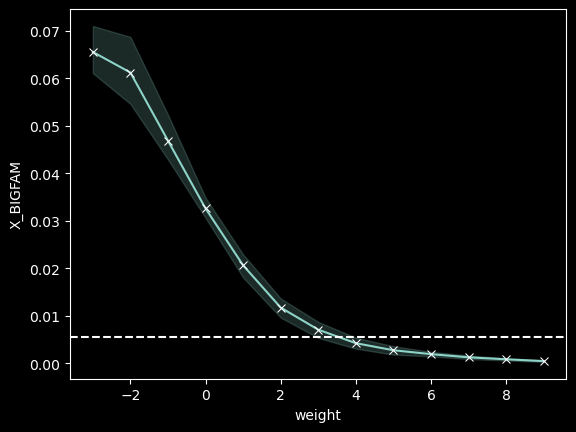

In [34]:
sns.lineplot(
    data=df_mrg_filtered,
    x="weight",
    y="X_BIGFAM",
    marker="x")
plt.axhline(df_mrg_filtered["X_GCTA"].mean(), ls="--")

In [28]:
df_corr = pd.DataFrame(columns=["weight", "type", "corr"])

for w in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[(df_mrg["weight"] == w)]
    tmp_pos = df_mrg_filtered[df_mrg_filtered["weight"] == w]
    # tmp = tmp[~tmp["pheno"].isin(excludes)]
    
    corr = tmp[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
    corr_pos = tmp_pos[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
    
    df_corr.loc[len(df_corr)] = [w, "all", corr]
    df_corr.loc[len(df_corr)] = [w, "pos", corr_pos]

<Axes: xlabel='weight', ylabel='corr'>

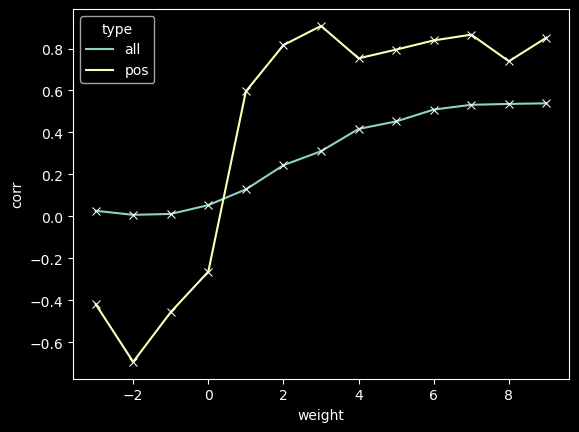

In [29]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="type",
    marker="x"
)

In [31]:
# dict_pc = {}
# for p in df_mrg_filtered["pheno"].unique():
#     tmp = df_mrg_filtered[(df_mrg_filtered["weight"] == 7) \
#                         & (df_mrg_filtered["pheno"] != p)]
#     dict_pc[p] = tmp[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
    
# pd.DataFrame(dict_pc, index=["cnt"]).T.sort_values(by="cnt")



In [ ]:
# df_corr = pd.DataFrame(columns=["w1", "w2", "pheno"])

# for w in sorted(df_mrg["pheno"].unique()):
#     tmp2 = df_mrg[(df_mrg["weight"] == w)]
#     tmp_pos = df_mrg_filtered[df_mrg_filtered["weight"] == w]
#     # tmp = tmp[~tmp["pheno"].isin(excludes)]
    
#     corr = tmp[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
#     corr_pos = tmp_pos[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
    
#     df_corr.loc[len(df_corr)] = [w, "all", corr]
#     df_corr.loc[len(df_corr)] = [w, "pos", corr_pos]

In [37]:
for_plot = df_mrg_filtered[df_mrg_filtered["weight"] == 3]

for_plot[["X_BIGFAM", "X_GCTA"]].mean()

X_BIGFAM    0.007061
X_GCTA      0.005281
dtype: float64

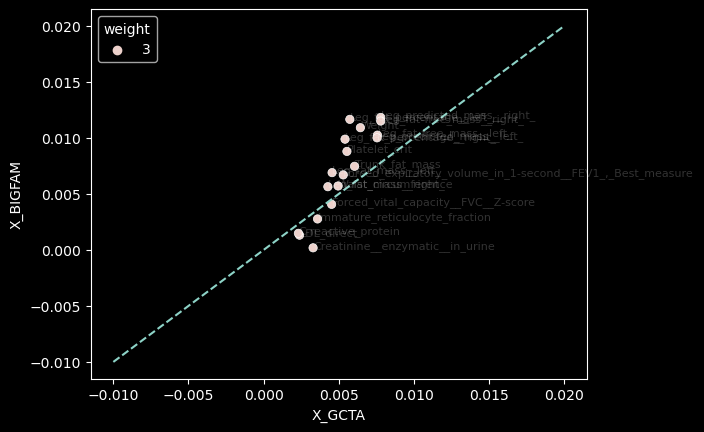

In [38]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=for_plot,
    x="X_GCTA",
    y="X_BIGFAM",
    hue="weight",
    ax=ax)
ax.plot([-0.01, 0.02], [-0.01, 0.02], ls="--")

for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "X_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "X_BIGFAM"].values[0]
    ax.annotate(pheno, (x, y), fontsize=8, alpha=0.2)

# Stpe 3. estimate XmXf

In [ ]:
df_bigfam = pd.DataFrame(
    columns=["pheno", "weight", 
             "Xmale_BIGFAM", "lowerXmale_BIGFAM", "upperXmale_BIGFAM",
             "Xfemale_BIGFAM", "lowerXfemale_BIGFAM", "upperXfemale_BIGFAM",]
)

for pheno_fn in tqdm(pheno_fns):
    pheno = pheno_fn.split(".")[0]
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    # regress out mean
    for alp in range(-3, 10):
        result = obj2.estimateXmXf(df_frreg, 
                                alpha_dicts={"type": "eta", "weight":alp})
        df_bigfam.loc[len(df_bigfam)] = [pheno, alp, 
                                         np.median(result["Xmale"]),
                                         np.percentile(result["Xmale"], 2.5), 
                                         np.percentile(result["Xmale"], 97.5),
                                         np.median(result["Xfemale"]),
                                         np.percentile(result["Xfemale"], 2.5), 
                                         np.percentile(result["Xfemale"], 97.5)]

In [19]:
df_bigfam = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/test/varing_weight.mf.tsv",
    sep='\t'
)

In [145]:
df_mrg = pd.merge(df_bigfam, df_ta, on="pheno")
excludes = ["Sitting_height", 
            "Platelet_count", 
            "SHBG",
            ]
df_mrg = (df_mrg[~df_mrg["pheno"].isin(excludes)]
          .reset_index(drop=True))

In [146]:
len(df_mrg["pheno"].unique())

103

### Step 2.2.1 plot correlation

In [151]:
x_thred = 1e-4

In [152]:
# df_mrg_filtered = (df_mrg[(df_mrg["lowerXmale_BIGFAM"] > x_thred)\
#                         & (df_mrg["lowerXfemale_BIGFAM"] > x_thred)\
#                         & (df_mrg["lowerXmale_GCTA"] > x_thred)\
#                         & (df_mrg["lowerXfemale_GCTA"] > x_thred)]
#                    .reset_index(drop=True))

df_mrg_filtered = (df_mrg[(df_mrg["Xmale_BIGFAM"] > x_thred)\
                        & (df_mrg["Xfemale_BIGFAM"] > x_thred)\
                        & (df_mrg["Xmale_GCTA"] > x_thred)\
                        & (df_mrg["Xfemale_GCTA"] > x_thred)]
                   .reset_index(drop=True))

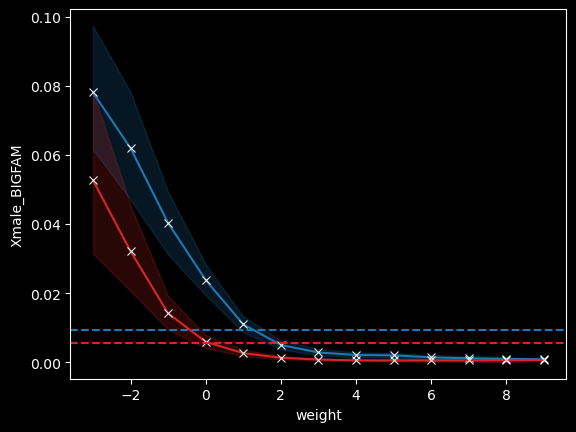

In [153]:
sns.lineplot(
    data=df_mrg_filtered,
    x="weight",
    y="Xmale_BIGFAM",
    color="tab:blue",
    marker="x")

plt.axhline(df_mrg_filtered["Xmale_GCTA"].mean(), 
            color="tab:blue", 
            ls="--")

sns.lineplot(
    data=df_mrg_filtered,
    x="weight",
    y="Xfemale_BIGFAM",
    color="tab:red", 
    marker="x")
plt.axhline(df_mrg_filtered["Xfemale_GCTA"].mean(), 
            color="tab:red", 
            ls="--")

In [154]:
df_corr = pd.DataFrame(columns=["weight", "type", "corr"])

for w in sorted(df_mrg["weight"].unique()):
    tmp_pos = df_mrg_filtered[df_mrg_filtered["weight"] == w]
    
    corr_male = tmp_pos[["Xmale_BIGFAM", "Xmale_GCTA"]].corr().iloc[0, 1]
    corr_female = tmp_pos[["Xfemale_BIGFAM", "Xfemale_GCTA"]].corr().iloc[0, 1]
    
    df_corr.loc[len(df_corr)] = [w, "male", corr_male]
    df_corr.loc[len(df_corr)] = [w, "female", corr_female]

<Axes: xlabel='weight', ylabel='corr'>

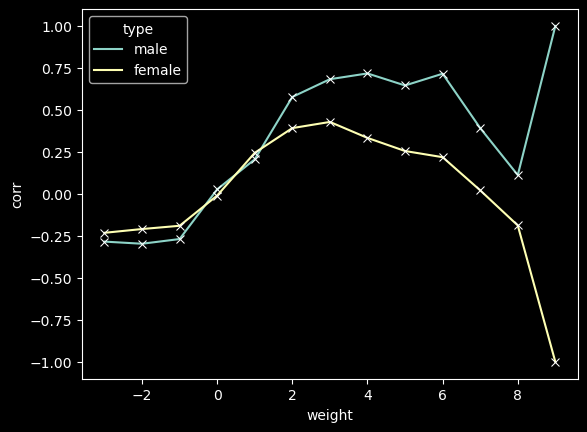

In [155]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="type",
    marker="x"
)

In [160]:
for_plot = df_mrg_filtered[df_mrg_filtered["weight"] == 2]

plot_male = for_plot[["Xmale_BIGFAM", "Xmale_GCTA"]]
plot_female = for_plot[["Xfemale_BIGFAM", "Xfemale_GCTA"]]

print(for_plot[["Xmale_BIGFAM", "Xmale_GCTA"]].mean())
print(for_plot[["Xfemale_BIGFAM", "Xfemale_GCTA"]].mean())

Xmale_BIGFAM    0.005011
Xmale_GCTA      0.008735
dtype: float64
Xfemale_BIGFAM    0.001318
Xfemale_GCTA      0.005225
dtype: float64


In [157]:
# fig, ax = plt.subplots()

# sns.scatterplot(
#     data=for_plot,
#     x="Xmale_GCTA",
#     y="Xfemale_GCTA",
#     ax=ax
# )

# sns.scatterplot(
#     data=for_plot,
#     x="Xmale_BIGFAM",
#     y="Xfemale_BIGFAM",
#     ax=ax
# )

# ax.plot([-0.001, 0.02], [-0.001, 0.02], ls="--")

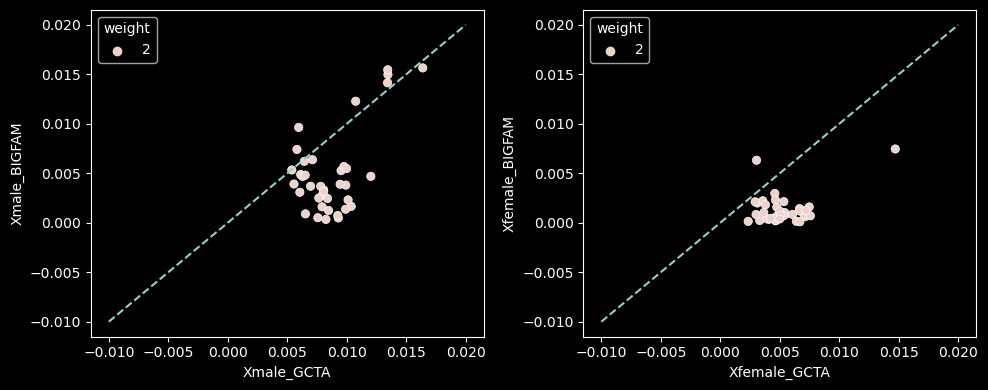

In [161]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(
    data=for_plot,
    x="Xmale_GCTA",
    y="Xmale_BIGFAM",
    hue="weight",
    ax=axs[0])
axs[0].plot([-0.01, 0.02], [-0.01, 0.02], ls="--")

sns.scatterplot(
    data=for_plot,
    x="Xfemale_GCTA",
    y="Xfemale_BIGFAM",
    hue="weight",
    ax=axs[1])
axs[1].plot([-0.01, 0.02], [-0.01, 0.02], ls="--")

# for i, pheno in enumerate(for_plot["pheno"]):
#     x = for_plot.loc[for_plot["pheno"] == pheno, "Xmale_GCTA"].values[0]
#     y = for_plot.loc[for_plot["pheno"] == pheno, "Xmale_BIGFAM"].values[0]
#     ax.annotate(pheno, (x, y), fontsize=8, alpha=0.2)

plt.tight_layout();